# Plot emotions

In [5]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import pandas as pd


DATA_DIR = Path("../data")
VERSION_DIR = DATA_DIR / "v2"
PLOTS_DIR = DATA_DIR / "final_plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

BSKY_PATH = VERSION_DIR / "bsky_final.csv"
YOUTUBE_PATH = VERSION_DIR / "youtube_final.csv"

AGGREGATION_FREQ = "45D"
AGGREGATION_LABEL = AGGREGATION_FREQ.lower()

# Load datasets

In [6]:
bsky_df = pd.read_csv(BSKY_PATH)
youtube_df = pd.read_csv(YOUTUBE_PATH)

print(f"Bluesky rows: {len(bsky_df):,}")
print(f"YouTube rows: {len(youtube_df):,}")

Bluesky rows: 10,858
YouTube rows: 14,566


# Emotion proportions

In [7]:
EMOTION_ORDER = ["anger", "disgust", "fear", "joy", "sadness", "surprise"]
SENTIMENT_ORDER = ["negative", "positive"]
EMOTION_COLORS = {
    "anger": "#C44E52",
    "disgust": "#8172B2",
    "fear": "#4C72B0",
    "joy": "#55A868",
    "sadness": "#937860",
    "surprise": "#DD8452",
}
SENTIMENT_COLORS = {
    "negative": "#C44E52",
    "positive": "#55A868",
}


def emotion_proportions(df, emotion_col="Emotion"):
    filtered_df = df[df[emotion_col].str.lower() != "neutral"].copy()
    counts = filtered_df[emotion_col].str.lower().value_counts()
    proportions = counts / counts.sum()
    return proportions.reindex(EMOTION_ORDER, fill_value=0)


def plot_emotion_proportions(df, dataset_name, output_path, emotion_col="Emotion"):
    proportions = emotion_proportions(df, emotion_col=emotion_col)

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(
        proportions.index,
        proportions.values,
        color=[EMOTION_COLORS[emotion] for emotion in proportions.index],
    )

    ax.set_title(f"{dataset_name} Emotion Distribution")
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Proportion of posts")
    ax.set_ylim(0, max(proportions.max() * 1.15, 0.05))
    ax.grid(axis="y", alpha=0.3)

    for bar, value in zip(bars, proportions.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.1%}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

    fig.autofmt_xdate(rotation=0)
    plt.tight_layout()

    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot to {output_path}")
    return fig, ax, proportions


def emotion_evolution_proportions(
    df,
    date_col,
    emotion_col="Emotion",
    aggregation_freq=AGGREGATION_FREQ,
):
    dated_df = df.copy()
    dated_df[date_col] = pd.to_datetime(
        dated_df[date_col],
        utc=True,
        errors="coerce",
        format="mixed",
    )
    dated_df = dated_df.dropna(subset=[date_col, emotion_col]).copy()
    dated_df[emotion_col] = dated_df[emotion_col].str.lower()

    total_counts = dated_df.groupby(pd.Grouper(key=date_col, freq=aggregation_freq)).size()
    emotion_counts = (
        dated_df[dated_df[emotion_col].isin(EMOTION_ORDER)]
        .groupby([pd.Grouper(key=date_col, freq=aggregation_freq), emotion_col])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=EMOTION_ORDER, fill_value=0)
    )

    proportions = emotion_counts.div(total_counts, axis=0).fillna(0)
    return proportions


def plot_emotion_evolution(
    df,
    dataset_name,
    date_col,
    output_path,
    emotion_col="Emotion",
    aggregation_freq=AGGREGATION_FREQ,
):
    proportions = emotion_evolution_proportions(
        df,
        date_col=date_col,
        emotion_col=emotion_col,
        aggregation_freq=aggregation_freq,
    )

    fig, ax = plt.subplots(figsize=(14, 7))
    for emotion in EMOTION_ORDER:
        ax.plot(
            proportions.index,
            proportions[emotion],
            marker="o",
            linewidth=2,
            label=emotion,
            color=EMOTION_COLORS[emotion],
        )

    ax.set_title(f"{dataset_name} Emotion Evolution, {aggregation_freq} Aggregation")
    ax.set_xlabel("Date")
    ax.set_ylabel("Proportion of total posts")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Emotion", ncol=2)

    fig.autofmt_xdate()
    plt.tight_layout()

    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot to {output_path}")
    return fig, ax, proportions


def plot_combined_emotion_evolution(
    dataset_specs,
    output_path,
    emotion_col="Emotion",
    aggregation_freq=AGGREGATION_FREQ,
):
    proportions_by_dataset = {
        dataset_name: emotion_evolution_proportions(
            df,
            date_col=date_col,
            emotion_col=emotion_col,
            aggregation_freq=aggregation_freq,
        )
        for dataset_name, (df, date_col) in dataset_specs.items()
    }
    max_value = max(proportions.max().max() for proportions in proportions_by_dataset.values())

    fig, axes = plt.subplots(1, len(proportions_by_dataset), figsize=(24, 8), sharey=True)
    if len(proportions_by_dataset) == 1:
        axes = [axes]

    legend_handles = None
    legend_labels = None
    for ax, (dataset_name, proportions) in zip(axes, proportions_by_dataset.items()):
        for emotion in EMOTION_ORDER:
            ax.plot(
                proportions.index,
                proportions[emotion],
                marker="o",
                linewidth=2.5,
                label=emotion,
                color=EMOTION_COLORS[emotion],
            )
        _bold_axis_labels(ax, dataset_name, "Date", "Proportion of total posts")
        ax.set_ylim(0, max(max_value * 1.08, 0.05))
        ax.grid(True, alpha=0.3)
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            legend_handles, legend_labels = handles, labels

    fig.suptitle(
        f"Emotion Evolution, {aggregation_freq} Aggregation",
        fontsize=28,
        fontweight="bold",
        y=0.98,
    )
    fig.legend(
        legend_handles,
        legend_labels,
        title="Emotion",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=3,
        fontsize=21,
        title_fontsize=23,
        frameon=False,
    )
    fig.autofmt_xdate()
    fig.tight_layout(rect=(0, 0.14, 1, 0.93))
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot to {output_path}")
    return fig, axes, proportions_by_dataset


def sentiment_proportions(df, sentiment_col="FinBERT_Sentiment"):
    filtered_df = df[df[sentiment_col].str.lower() != "neutral"].copy()
    counts = filtered_df[sentiment_col].str.lower().value_counts()
    proportions = counts / counts.sum()
    return proportions.reindex(SENTIMENT_ORDER, fill_value=0)


def plot_sentiment_proportions(
    df,
    dataset_name,
    output_path,
    sentiment_col="FinBERT_Sentiment",
):
    proportions = sentiment_proportions(df, sentiment_col=sentiment_col)

    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.bar(
        proportions.index,
        proportions.values,
        color=[SENTIMENT_COLORS[sentiment] for sentiment in proportions.index],
    )

    ax.set_title(f"{dataset_name} FinBERT Sentiment Distribution")
    ax.set_xlabel("FinBERT sentiment")
    ax.set_ylabel("Proportion of comments")
    ax.set_ylim(0, max(proportions.max() * 1.15, 0.05))
    ax.grid(axis="y", alpha=0.3)

    for bar, value in zip(bars, proportions.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.1%}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

    fig.autofmt_xdate(rotation=0)
    plt.tight_layout()

    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot to {output_path}")
    return fig, ax, proportions


def sentiment_by_emotion_proportions(
    df,
    emotion_col="Emotion",
    sentiment_col="FinBERT_Sentiment",
):
    sentiment_df = df.copy()
    sentiment_df[emotion_col] = sentiment_df[emotion_col].str.lower()
    sentiment_df[sentiment_col] = sentiment_df[sentiment_col].str.lower()
    sentiment_df = sentiment_df[
        sentiment_df[emotion_col].isin(EMOTION_ORDER)
        & sentiment_df[sentiment_col].isin(SENTIMENT_ORDER)
    ]

    counts = (
        sentiment_df
        .groupby([emotion_col, sentiment_col])
        .size()
        .unstack(fill_value=0)
        .reindex(index=EMOTION_ORDER, columns=SENTIMENT_ORDER, fill_value=0)
    )
    proportions = counts.div(counts.sum(axis=1), axis=0).fillna(0)
    return proportions


def plot_sentiment_by_emotion(
    df,
    dataset_name,
    output_path,
    emotion_col="Emotion",
    sentiment_col="FinBERT_Sentiment",
):
    proportions = sentiment_by_emotion_proportions(
        df,
        emotion_col=emotion_col,
        sentiment_col=sentiment_col,
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    bottom = pd.Series(0, index=proportions.index, dtype=float)
    for sentiment in SENTIMENT_ORDER:
        ax.bar(
            proportions.index,
            proportions[sentiment],
            bottom=bottom,
            label=sentiment,
            color=SENTIMENT_COLORS[sentiment],
        )
        bottom += proportions[sentiment]

    ax.set_title(f"{dataset_name} FinBERT Sentiment by Emotion")
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Proportion of FinBERT sentiment")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="FinBERT sentiment")

    for emotion_index, emotion in enumerate(proportions.index):
        cumulative = 0
        for sentiment in SENTIMENT_ORDER:
            value = proportions.loc[emotion, sentiment]
            if value > 0.03:
                ax.text(
                    emotion_index,
                    cumulative + value / 2,
                    f"{value:.0%}",
                    ha="center",
                    va="center",
                    color="white",
                    fontsize=10,
                    fontweight="bold",
                )
            cumulative += value

    fig.autofmt_xdate(rotation=0)
    plt.tight_layout()

    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot to {output_path}")
    return fig, ax, proportions


def _bold_axis_labels(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=24, fontweight="bold", pad=18)
    ax.set_xlabel(xlabel, fontsize=18, fontweight="bold", labelpad=12)
    ax.set_ylabel(ylabel, fontsize=18, fontweight="bold", labelpad=12)
    ax.tick_params(axis="x", labelsize=15)
    ax.tick_params(axis="y", labelsize=14)
    for tick_label in ax.get_xticklabels():
        tick_label.set_fontweight("bold")
    for tick_label in ax.get_yticklabels():
        tick_label.set_fontweight("bold")
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.5)


def _label_bars(ax, bars, values, y_limit):
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + y_limit * 0.01,
            f"{value:.1%}",
            ha="center",
            va="bottom",
            fontsize=13,
            fontweight="bold",
        )


def plot_combined_emotion_proportions(datasets, output_path, emotion_col="Emotion"):
    proportions_by_dataset = {
        dataset_name: emotion_proportions(df, emotion_col=emotion_col)
        for dataset_name, df in datasets.items()
    }
    max_value = max(proportions.max() for proportions in proportions_by_dataset.values())
    y_limit = max(max_value * 1.08, 0.05)

    fig, axes = plt.subplots(1, len(proportions_by_dataset), figsize=(18, 7), sharey=True)
    if len(proportions_by_dataset) == 1:
        axes = [axes]

    for ax, (dataset_name, proportions) in zip(axes, proportions_by_dataset.items()):
        bars = ax.bar(
            proportions.index,
            proportions.values,
            width=0.72,
            color=[EMOTION_COLORS[emotion] for emotion in proportions.index],
            edgecolor="black",
            linewidth=1.5,
        )
        _bold_axis_labels(ax, dataset_name, "Emotion", "Proportion of posts")
        ax.set_ylim(0, y_limit)
        ax.grid(axis="y", alpha=0.3)
        _label_bars(ax, bars, proportions.values, y_limit)

    fig.suptitle("Emotion Distribution", fontsize=28, fontweight="bold", y=0.98)
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot to {output_path}")
    return fig, axes, proportions_by_dataset


def plot_combined_sentiment_proportions(
    datasets,
    output_path,
    sentiment_col="FinBERT_Sentiment",
):
    proportions_by_dataset = {
        dataset_name: sentiment_proportions(df, sentiment_col=sentiment_col)
        for dataset_name, df in datasets.items()
    }
    max_value = max(proportions.max() for proportions in proportions_by_dataset.values())
    y_limit = max(max_value * 1.08, 0.05)

    fig, axes = plt.subplots(1, len(proportions_by_dataset), figsize=(15, 7), sharey=True)
    if len(proportions_by_dataset) == 1:
        axes = [axes]

    for ax, (dataset_name, proportions) in zip(axes, proportions_by_dataset.items()):
        bars = ax.bar(
            proportions.index,
            proportions.values,
            width=0.62,
            color=[SENTIMENT_COLORS[sentiment] for sentiment in proportions.index],
            edgecolor="black",
            linewidth=1.5,
        )
        _bold_axis_labels(ax, dataset_name, "FinBERT sentiment", "Proportion of comments")
        ax.set_ylim(0, y_limit)
        ax.grid(axis="y", alpha=0.3)
        _label_bars(ax, bars, proportions.values, y_limit)

    fig.suptitle("FinBERT Sentiment Distribution", fontsize=28, fontweight="bold", y=0.98)
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot to {output_path}")
    return fig, axes, proportions_by_dataset


def plot_combined_sentiment_by_emotion(
    datasets,
    output_path,
    emotion_col="Emotion",
    sentiment_col="FinBERT_Sentiment",
):
    proportions_by_dataset = {
        dataset_name: sentiment_by_emotion_proportions(
            df,
            emotion_col=emotion_col,
            sentiment_col=sentiment_col,
        )
        for dataset_name, df in datasets.items()
    }

    fig, axes = plt.subplots(1, len(proportions_by_dataset), figsize=(22, 8), sharey=True)
    if len(proportions_by_dataset) == 1:
        axes = [axes]

    legend_handles = None
    legend_labels = None
    for ax, (dataset_name, proportions) in zip(axes, proportions_by_dataset.items()):
        bottom = pd.Series(0, index=proportions.index, dtype=float)
        for sentiment in SENTIMENT_ORDER:
            bars = ax.bar(
                proportions.index,
                proportions[sentiment],
                width=0.78,
                bottom=bottom,
                label=sentiment,
                color=SENTIMENT_COLORS[sentiment],
                edgecolor="black",
                linewidth=1.5,
            )
            bottom += proportions[sentiment]

        _bold_axis_labels(ax, dataset_name, "Emotion", "Proportion of FinBERT sentiment")
        ax.set_ylim(0, 1.02)
        ax.grid(axis="y", alpha=0.3)
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            legend_handles, legend_labels = handles, labels

        for emotion_index, emotion in enumerate(proportions.index):
            cumulative = 0
            for sentiment in SENTIMENT_ORDER:
                value = proportions.loc[emotion, sentiment]
                if value > 0.03:
                    ax.text(
                        emotion_index,
                        cumulative + value / 2,
                        f"{value:.0%}",
                        ha="center",
                        va="center",
                        color="white",
                        fontsize=12,
                        fontweight="bold",
                    )
                cumulative += value

    fig.suptitle("FinBERT Sentiment by Emotion", fontsize=28, fontweight="bold", y=0.98)
    fig.legend(
        legend_handles,
        legend_labels,
        title="FinBERT sentiment",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=len(SENTIMENT_ORDER),
        fontsize=21,
        title_fontsize=23,
        frameon=False,
    )
    fig.tight_layout(rect=(0, 0.14, 1, 0.93))
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot to {output_path}")
    return fig, axes, proportions_by_dataset

# Combined emotion distribution

Saved plot to ../data/final_plots/combined_emotion_distribution.png


,Emotion,proportion
0,anger,0.162264
1,disgust,0.032337
2,fear,0.234589
3,joy,0.243251
4,sadness,0.100909
5,surprise,0.226649


,Emotion,proportion
0,anger,0.247357
1,disgust,0.265481
2,fear,0.152822
3,joy,0.098654
4,sadness,0.138816
5,surprise,0.096869


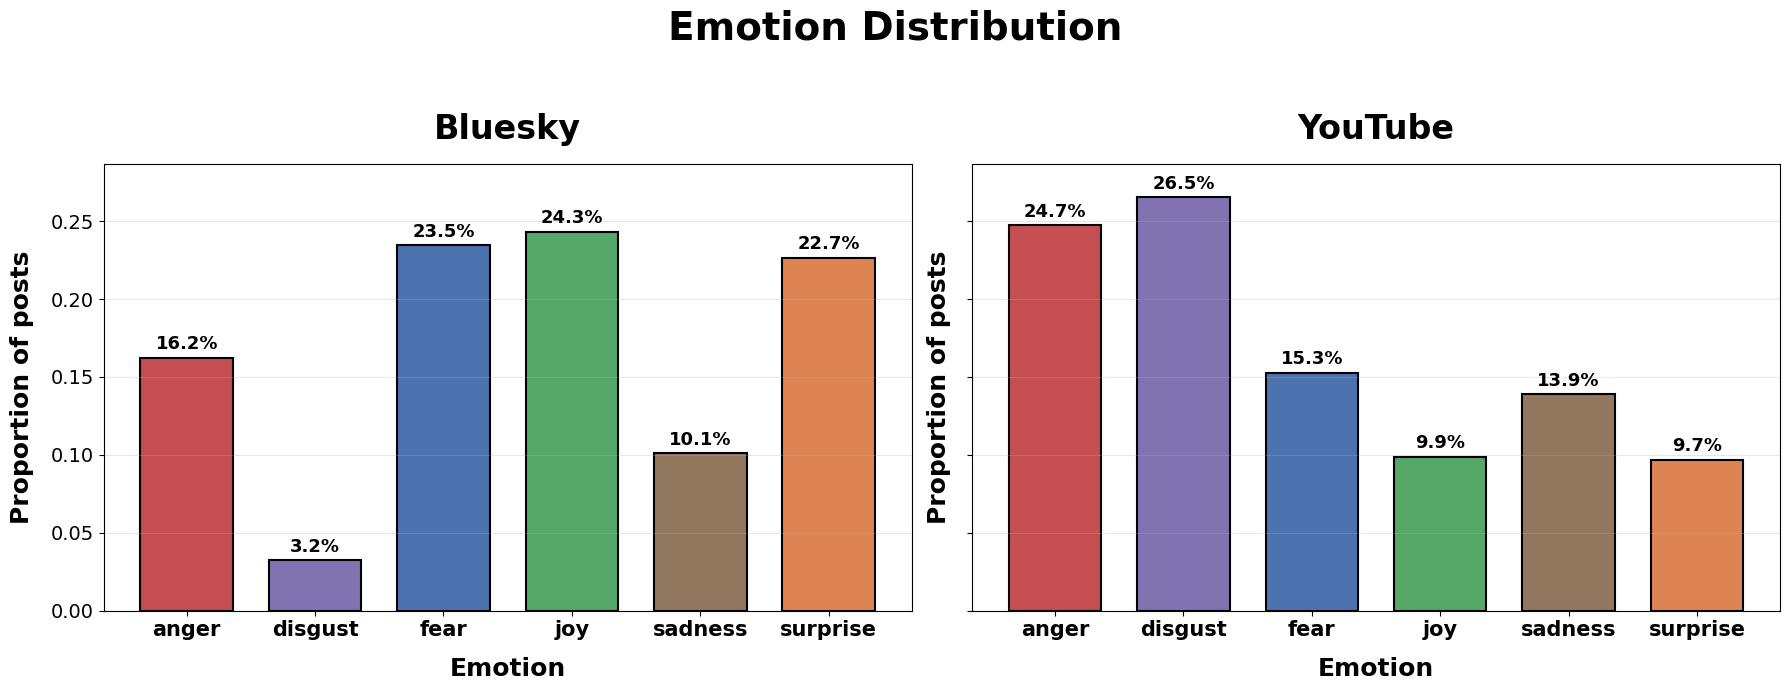

In [8]:
combined_emotion_fig, combined_emotion_axes, combined_emotion_proportions = plot_combined_emotion_proportions(
    {"Bluesky": bsky_df, "YouTube": youtube_df},
    output_path=PLOTS_DIR / "combined_emotion_distribution.png",
)

bsky_emotion_proportions = combined_emotion_proportions["Bluesky"]
youtube_emotion_proportions = combined_emotion_proportions["YouTube"]

display(bsky_emotion_proportions.rename("proportion").reset_index(name="proportion"))
display(youtube_emotion_proportions.rename("proportion").reset_index(name="proportion"))
plt.show()

# Emotion distribution tables

In [9]:
# Combined in the previous cell.


# Emotion evolution

Saved plot to ../data/final_plots/combined_emotion_evolution_45d.png


Emotion,anger,disgust,fear,joy,sadness,surprise
Date,,,,,,
2022-01-01 00:00:00+00:00,0.039474,0.000000,0.276316,0.263158,0.026316,0.052632
2022-02-15 00:00:00+00:00,0.070588,0.000000,0.352941,0.247059,0.023529,0.023529
2022-04-01 00:00:00+00:00,0.085366,0.012195,0.280488,0.182927,0.012195,0.121951
2022-05-16 00:00:00+00:00,0.080808,0.010101,0.252525,0.181818,0.040404,0.090909
2022-06-30 00:00:00+00:00,0.076923,0.000000,0.230769,0.186813,0.032967,0.131868


Emotion,anger,disgust,fear,joy,sadness,surprise
Comment_Date,,,,,,
2022-01-05 00:00:00+00:00,0.043478,0.173913,0.304348,0.260870,0.130435,0.086957
2022-02-19 00:00:00+00:00,0.147059,0.235294,0.088235,0.235294,0.117647,0.176471
2022-04-05 00:00:00+00:00,0.189944,0.273743,0.162011,0.089385,0.195531,0.089385
2022-05-20 00:00:00+00:00,0.200000,0.184615,0.261538,0.061538,0.230769,0.061538
2022-07-04 00:00:00+00:00,0.302789,0.250996,0.151394,0.099602,0.111554,0.083665


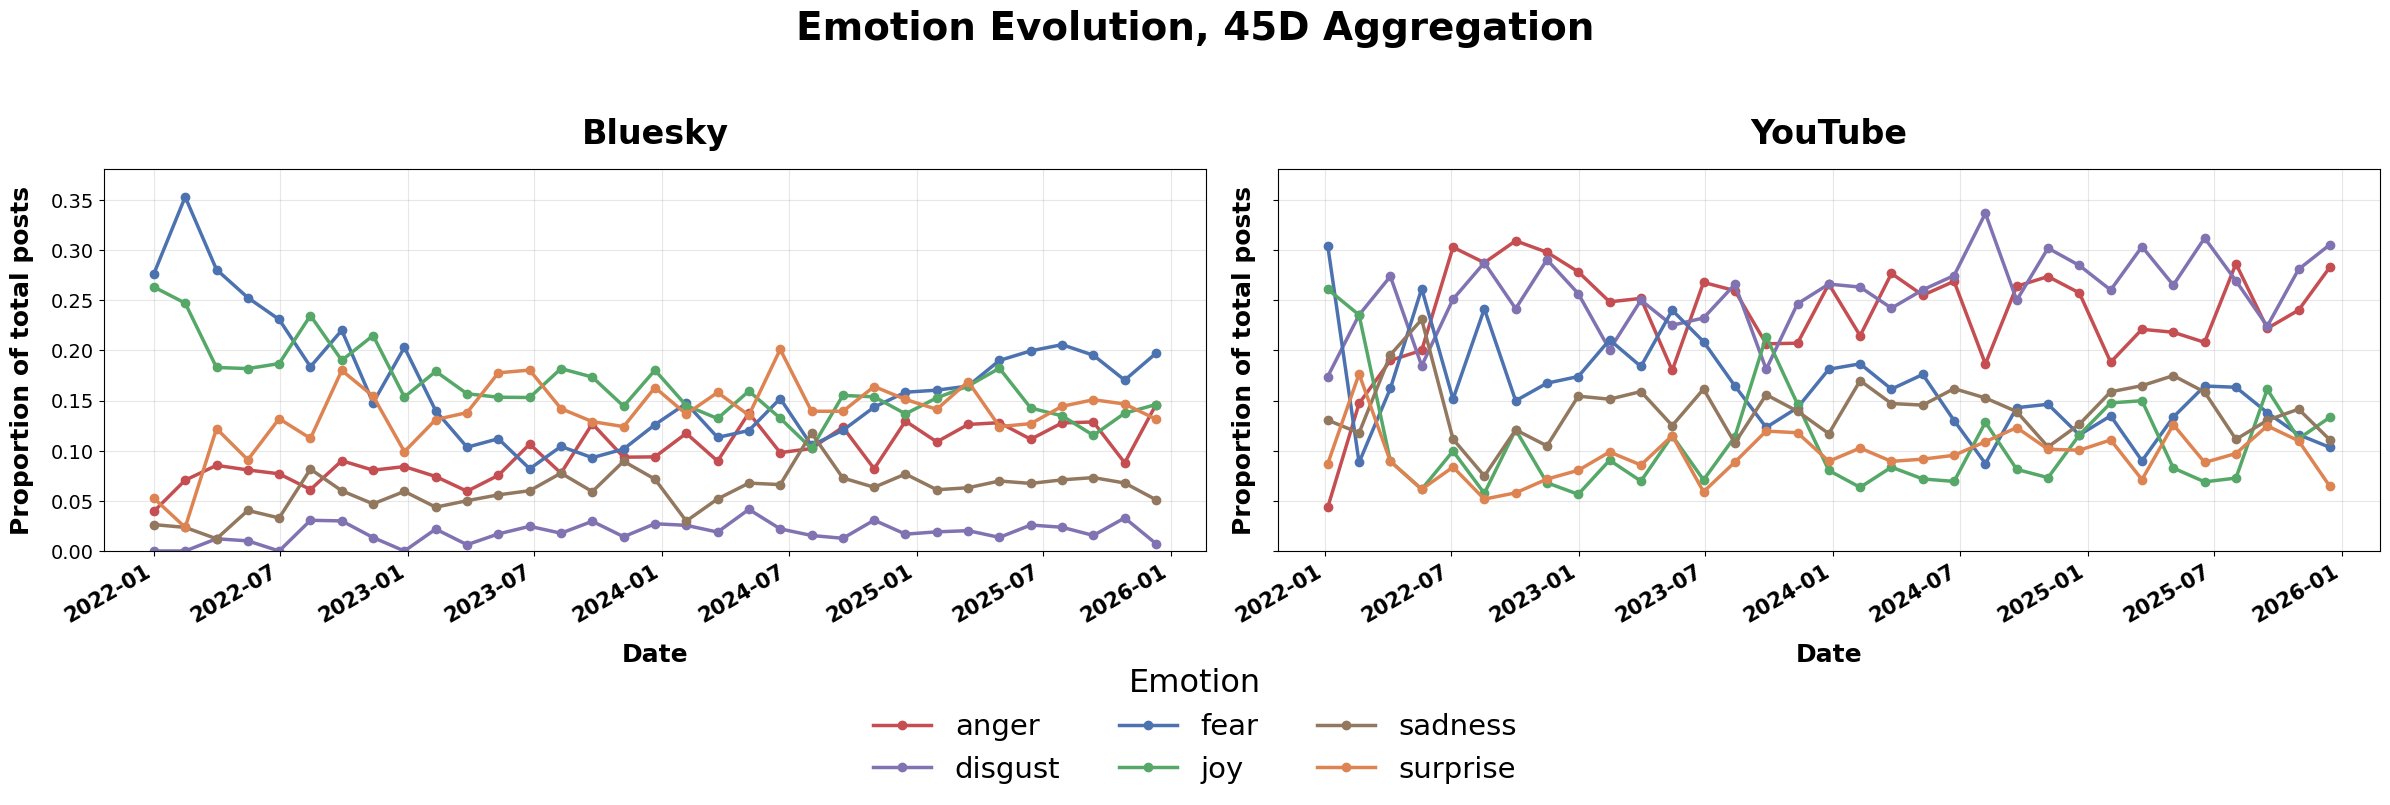

In [10]:
combined_evolution_fig, combined_evolution_axes, combined_evolution = plot_combined_emotion_evolution(
    {"Bluesky": (bsky_df, "Date"), "YouTube": (youtube_df, "Comment_Date")},
    output_path=PLOTS_DIR / f"combined_emotion_evolution_{AGGREGATION_LABEL}.png",
)

bsky_evolution = combined_evolution["Bluesky"]
youtube_evolution = combined_evolution["YouTube"]

display(bsky_evolution.head())
display(youtube_evolution.head())
plt.show()

In [11]:
# Combined in the previous cell.


# FinBERT sentiment distribution

Saved plot to ../data/final_plots/combined_finbert_sentiment_distribution.png


,FinBERT_Sentiment,proportion
0,negative,0.745625
1,positive,0.254375


,FinBERT_Sentiment,proportion
0,negative,0.884526
1,positive,0.115474


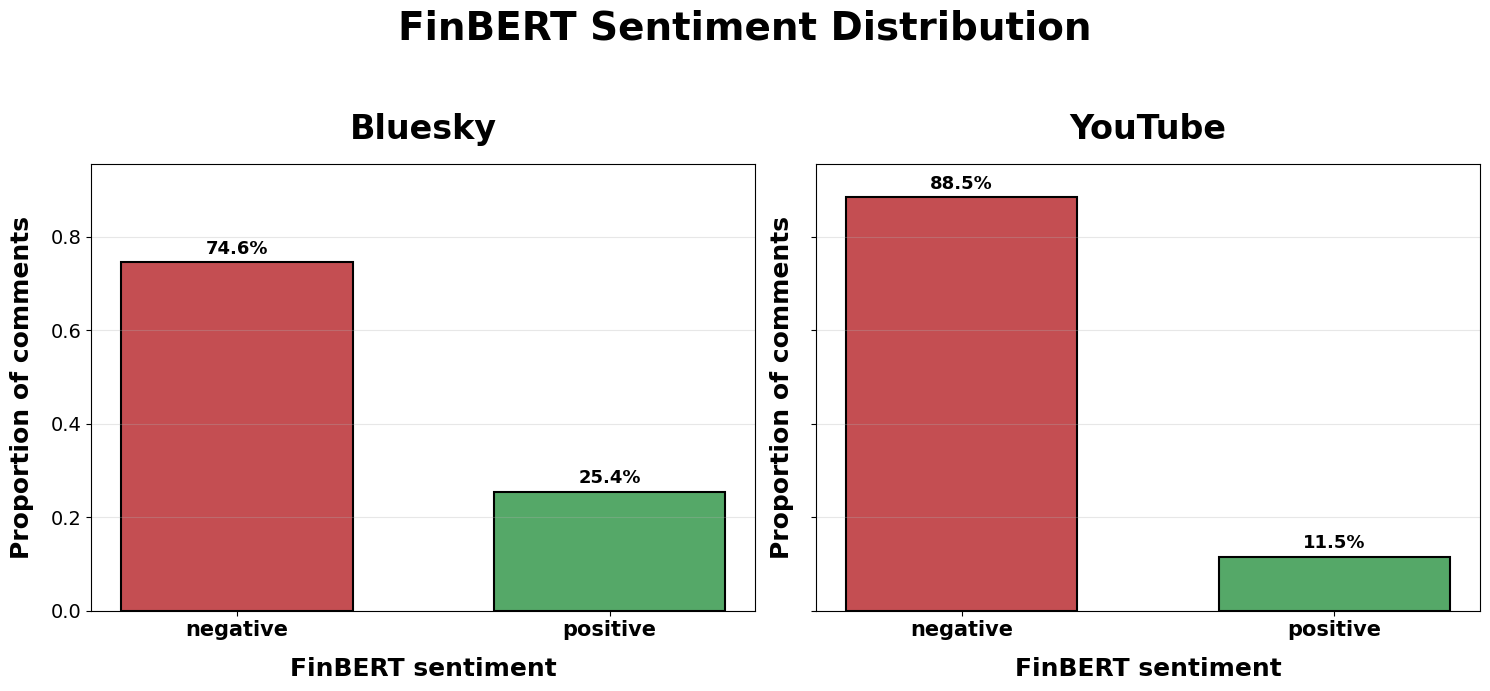

In [12]:
combined_sentiment_fig, combined_sentiment_axes, combined_sentiment_proportions = plot_combined_sentiment_proportions(
    {"Bluesky": bsky_df, "YouTube": youtube_df},
    output_path=PLOTS_DIR / "combined_finbert_sentiment_distribution.png",
)

bsky_sentiment_proportions = combined_sentiment_proportions["Bluesky"]
youtube_sentiment_proportions = combined_sentiment_proportions["YouTube"]

display(bsky_sentiment_proportions.rename("proportion").reset_index(name="proportion"))
display(youtube_sentiment_proportions.rename("proportion").reset_index(name="proportion"))
plt.show()

In [13]:
# Combined in the previous cell.


# FinBERT sentiment by emotion

Saved plot to ../data/final_plots/combined_finbert_sentiment_by_emotion.png


FinBERT_Sentiment,negative,positive
Emotion,,
anger,0.975232,0.024768
disgust,1.000000,0.000000
fear,0.853383,0.146617
joy,0.186275,0.813725
sadness,0.976096,0.023904
surprise,0.712575,0.287425


FinBERT_Sentiment,negative,positive
Emotion,,
anger,0.993894,0.006106
disgust,0.996380,0.003620
fear,0.982031,0.017969
joy,0.157272,0.842728
sadness,0.984669,0.015331
surprise,0.742027,0.257973


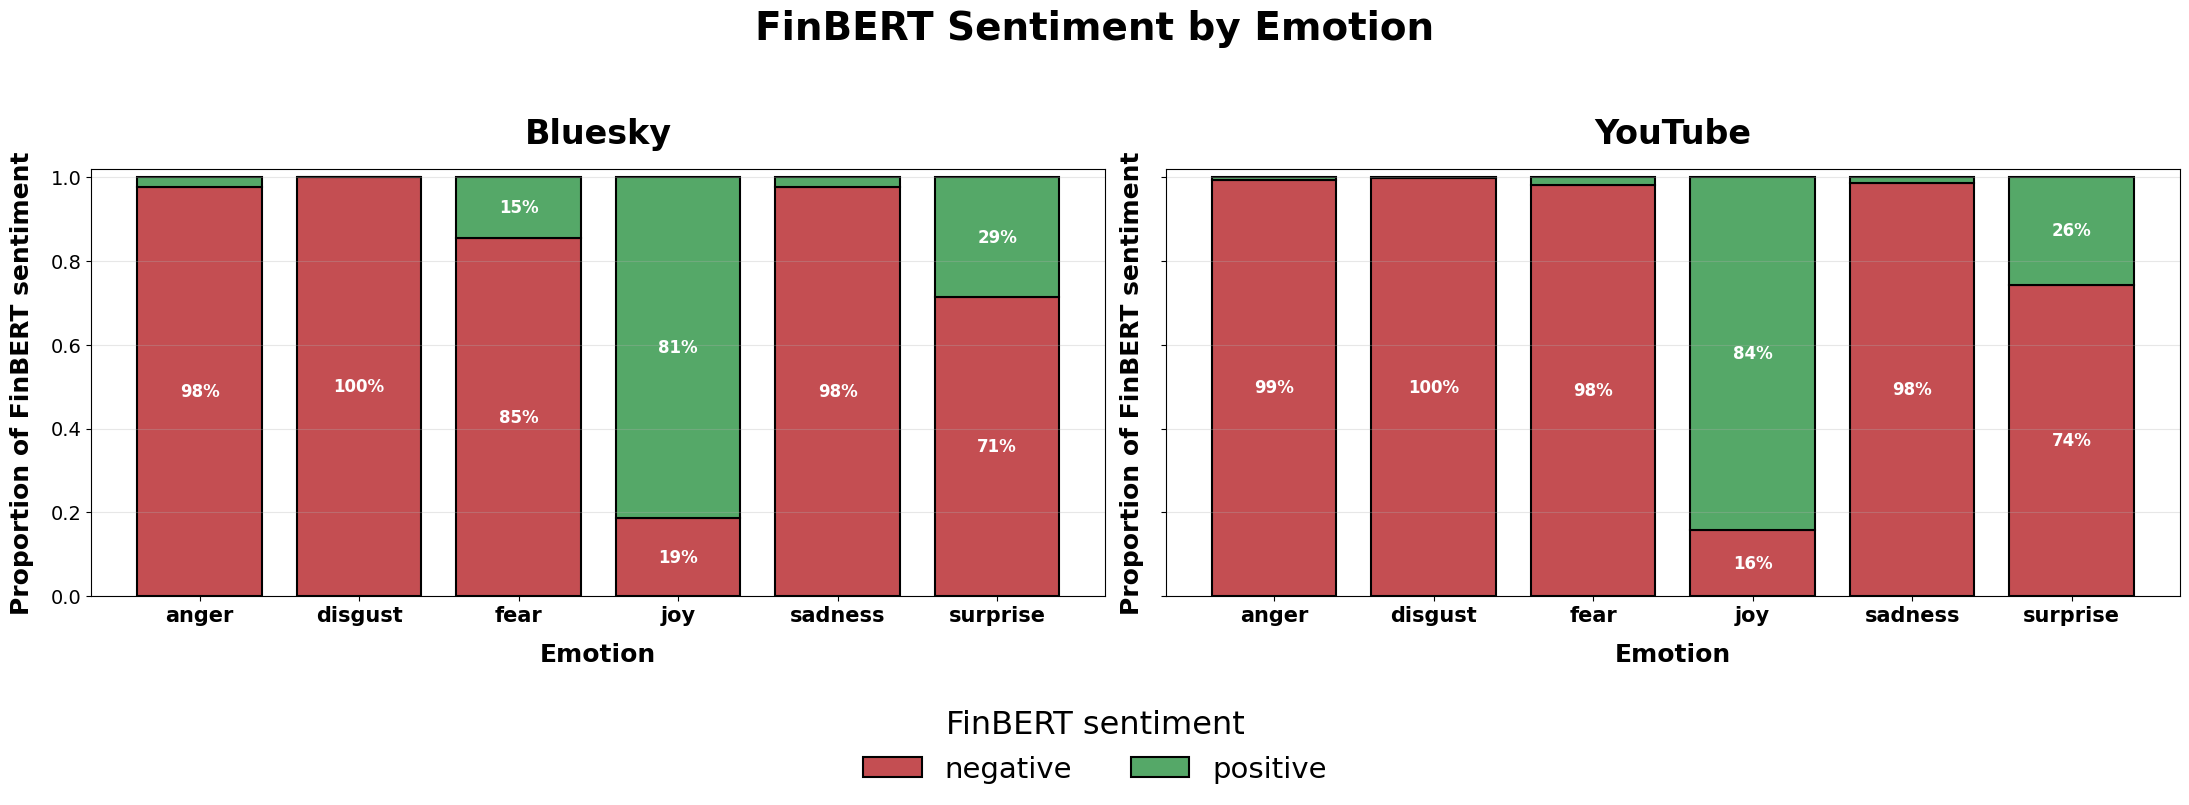

In [14]:
combined_sentiment_by_emotion_fig, combined_sentiment_by_emotion_axes, combined_sentiment_by_emotion = plot_combined_sentiment_by_emotion(
    {"Bluesky": bsky_df, "YouTube": youtube_df},
    output_path=PLOTS_DIR / "combined_finbert_sentiment_by_emotion.png",
)

bsky_sentiment_by_emotion = combined_sentiment_by_emotion["Bluesky"]
youtube_sentiment_by_emotion = combined_sentiment_by_emotion["YouTube"]

display(bsky_sentiment_by_emotion)
display(youtube_sentiment_by_emotion)
plt.show()

In [15]:
# Combined in the previous cell.


# Fear ratio versus AI assets

In [16]:
ASSET_TICKERS = ["AIQ", "CHAT", "NVDA"]


def aggregation_period_start(dates, aggregation_freq=AGGREGATION_FREQ, aggregation_origin=None):
    if aggregation_origin is None:
        aggregation_origin = dates.min()
    aggregation_origin = pd.Timestamp(aggregation_origin)
    aggregation_delta = pd.to_timedelta(aggregation_freq)
    period_number = ((dates - aggregation_origin) // aggregation_delta).astype(int)
    return aggregation_origin + period_number * aggregation_delta


def compute_fear_ratio(
    df,
    date_col,
    emotion_col="Emotion",
    aggregation_freq=AGGREGATION_FREQ,
    aggregation_origin=None,
):
    ratio_df = df.copy()
    ratio_df[date_col] = pd.to_datetime(
        ratio_df[date_col],
        utc=True,
        errors="coerce",
        format="mixed",
    ).dt.tz_convert(None).dt.normalize()
    ratio_df = ratio_df.dropna(subset=[date_col, emotion_col]).copy()
    ratio_df[emotion_col] = ratio_df[emotion_col].str.lower()
    ratio_df = ratio_df[ratio_df[emotion_col] != "neutral"]

    ratio_df["Aggregation_Period"] = aggregation_period_start(
        ratio_df[date_col],
        aggregation_freq=aggregation_freq,
        aggregation_origin=aggregation_origin,
    )

    total_counts = ratio_df.groupby("Aggregation_Period").size()
    fear_counts = ratio_df[ratio_df[emotion_col] == "fear"].groupby("Aggregation_Period").size()

    output = pd.concat(
        [total_counts.rename("total_posts"), fear_counts.rename("fear_posts")],
        axis=1,
        sort=True,
    ).fillna(0)
    output["fear_ratio"] = output["fear_posts"] / output["total_posts"]
    return output.dropna(subset=["fear_ratio"])


def _close_prices_from_yfinance(raw_prices):
    if isinstance(raw_prices.columns, pd.MultiIndex):
        if "Close" in raw_prices.columns.get_level_values(0):
            return raw_prices["Close"]
        if "Adj Close" in raw_prices.columns.get_level_values(0):
            return raw_prices["Adj Close"]
        if "Close" in raw_prices.columns.get_level_values(-1):
            return raw_prices.xs("Close", axis=1, level=-1)
        if "Adj Close" in raw_prices.columns.get_level_values(-1):
            return raw_prices.xs("Adj Close", axis=1, level=-1)
    return raw_prices[["Close"]]


def download_aggregated_asset_prices(
    tickers,
    start_date,
    end_date,
    aggregation_freq=AGGREGATION_FREQ,
    aggregation_origin=None,
):
    import yfinance as yf

    raw_prices = yf.download(
        tickers,
        start=start_date,
        end=end_date,
        auto_adjust=True,
        progress=False,
    )
    close_prices = _close_prices_from_yfinance(raw_prices)
    if isinstance(close_prices, pd.Series):
        close_prices = close_prices.to_frame(tickers[0])

    close_prices.index = pd.to_datetime(close_prices.index).tz_localize(None).normalize()
    close_prices = close_prices.copy()
    close_prices["Aggregation_Period"] = aggregation_period_start(
        close_prices.index.to_series(index=close_prices.index),
        aggregation_freq=aggregation_freq,
        aggregation_origin=aggregation_origin,
    )
    aggregated_prices = close_prices.groupby("Aggregation_Period").mean()
    return aggregated_prices.reindex(columns=tickers)


def minmax_scale(df):
    denominator = (df.max() - df.min()).replace(0, pd.NA)
    return (df - df.min()) / denominator


def align_fear_ratio_with_prices(fear_ratio_df, aggregated_prices):
    combined = fear_ratio_df[["fear_ratio"]].join(aggregated_prices, how="inner")
    return combined.dropna()


def fear_price_correlations(aligned_df, tickers=ASSET_TICKERS):
    return pd.Series(
        {ticker: aligned_df["fear_ratio"].corr(aligned_df[ticker]) for ticker in tickers},
        name="correlation",
    )


def plot_fear_ratio_with_prices(aligned_df, dataset_name, output_path, tickers=ASSET_TICKERS):
    scaled_prices = minmax_scale(aligned_df[tickers])

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(
        aligned_df.index,
        aligned_df["fear_ratio"],
        marker="o",
        linewidth=2.5,
        color="#4C72B0",
        label="Fear ratio",
    )

    for ticker in tickers:
        ax.plot(
            scaled_prices.index,
            scaled_prices[ticker],
            linewidth=2,
            label=f"{ticker} price",
        )

    ax.set_title(f"{dataset_name} Fear Ratio and AI Asset Prices, {AGGREGATION_FREQ} Aggregation")
    ax.set_xlabel("Date")
    ax.set_ylabel("Ratio / normalized price")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2)

    fig.autofmt_xdate()
    plt.tight_layout()

    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot to {output_path}")
    return fig, ax


def plot_combined_fear_ratio_with_prices(
    aligned_datasets,
    output_path,
    tickers=ASSET_TICKERS,
):
    scaled_prices_by_dataset = {
        dataset_name: minmax_scale(aligned_df[tickers])
        for dataset_name, aligned_df in aligned_datasets.items()
    }
    max_value = max(
        max(aligned_df["fear_ratio"].max(), scaled_prices_by_dataset[dataset_name].max().max())
        for dataset_name, aligned_df in aligned_datasets.items()
    )

    fig, axes = plt.subplots(1, len(aligned_datasets), figsize=(24, 8), sharey=True)
    if len(aligned_datasets) == 1:
        axes = [axes]

    for ax, (dataset_name, aligned_df) in zip(axes, aligned_datasets.items()):
        scaled_prices = scaled_prices_by_dataset[dataset_name]
        ax.plot(
            aligned_df.index,
            aligned_df["fear_ratio"],
            marker="o",
            linewidth=3,
            color="#4C72B0",
            label="Fear ratio",
        )

        for ticker in tickers:
            ax.plot(
                scaled_prices.index,
                scaled_prices[ticker],
                linewidth=2.5,
                label=f"{ticker} price",
            )

        _bold_axis_labels(ax, dataset_name, "Date", "Ratio / normalized price")
        ax.set_ylim(0, max(max_value * 1.05, 0.05))
        ax.grid(True, alpha=0.3)
        ax.legend(ncol=2, fontsize=21, title_fontsize=23)

    fig.suptitle(
        f"Fear Ratio and AI Asset Prices, {AGGREGATION_FREQ} Aggregation",
        fontsize=28,
        fontweight="bold",
        y=0.98,
    )
    fig.autofmt_xdate()
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot to {output_path}")
    return fig, axes


def plot_fear_price_correlations(correlation_df, output_path):
    fig, ax = plt.subplots(figsize=(10, 6))
    correlation_df.plot(
        kind="bar",
        ax=ax,
        color=["#4C72B0", "#DD8452"],
        width=0.78,
        edgecolor="black",
        linewidth=1.5,
    )

    _bold_axis_labels(ax, "Fear Ratio Correlation with AI Asset Prices", "Asset", "Correlation")
    ax.axhline(0, color="black", linewidth=1)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="Dataset", fontsize=17, title_fontsize=19)

    plt.xticks(rotation=0)
    plt.tight_layout()

    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot to {output_path}")
    return fig, ax


In [17]:
bsky_dates = pd.to_datetime(bsky_df["Date"], utc=True, errors="coerce", format="mixed").dt.tz_convert(None).dt.normalize()
youtube_dates = pd.to_datetime(youtube_df["Comment_Date"], utc=True, errors="coerce", format="mixed").dt.tz_convert(None).dt.normalize()
aggregation_origin = min(bsky_dates.min(), youtube_dates.min())

bsky_fear_ratio = compute_fear_ratio(
    bsky_df,
    date_col="Date",
    aggregation_freq=AGGREGATION_FREQ,
    aggregation_origin=aggregation_origin,
)
youtube_fear_ratio = compute_fear_ratio(
    youtube_df,
    date_col="Comment_Date",
    aggregation_freq=AGGREGATION_FREQ,
    aggregation_origin=aggregation_origin,
)

asset_start = aggregation_origin.date()
asset_end = (max(bsky_fear_ratio.index.max(), youtube_fear_ratio.index.max()) + pd.to_timedelta(AGGREGATION_FREQ)).date()

aggregated_asset_prices = download_aggregated_asset_prices(
    ASSET_TICKERS,
    start_date=asset_start,
    end_date=asset_end,
    aggregation_freq=AGGREGATION_FREQ,
    aggregation_origin=aggregation_origin,
)

bsky_fear_assets = align_fear_ratio_with_prices(bsky_fear_ratio, aggregated_asset_prices)
youtube_fear_assets = align_fear_ratio_with_prices(youtube_fear_ratio, aggregated_asset_prices)

display(bsky_fear_assets.head())
display(youtube_fear_assets.head())

,fear_ratio,AIQ,CHAT,NVDA
Aggregation_Period,,,,
2023-05-11,0.189300,26.123246,27.187016,36.862310
2023-06-25,0.135135,28.390989,28.506661,44.173719
2023-08-09,0.173432,27.747907,27.226697,45.041425
2023-09-23,0.152249,26.726678,26.100764,43.459247
2023-11-07,0.179211,29.479545,28.761978,47.925240


,fear_ratio,AIQ,CHAT,NVDA
Aggregation_Period,,,,
2023-05-11,0.242152,26.123246,27.187016,36.862310
2023-06-25,0.213115,28.390989,28.506661,44.173719
2023-08-09,0.176471,27.747907,27.226697,45.041425
2023-09-23,0.117647,26.726678,26.100764,43.459247
2023-11-07,0.140152,29.479545,28.761978,47.925240


Saved plot to ../data/final_plots/combined_fear_ratio_assets_45d.png


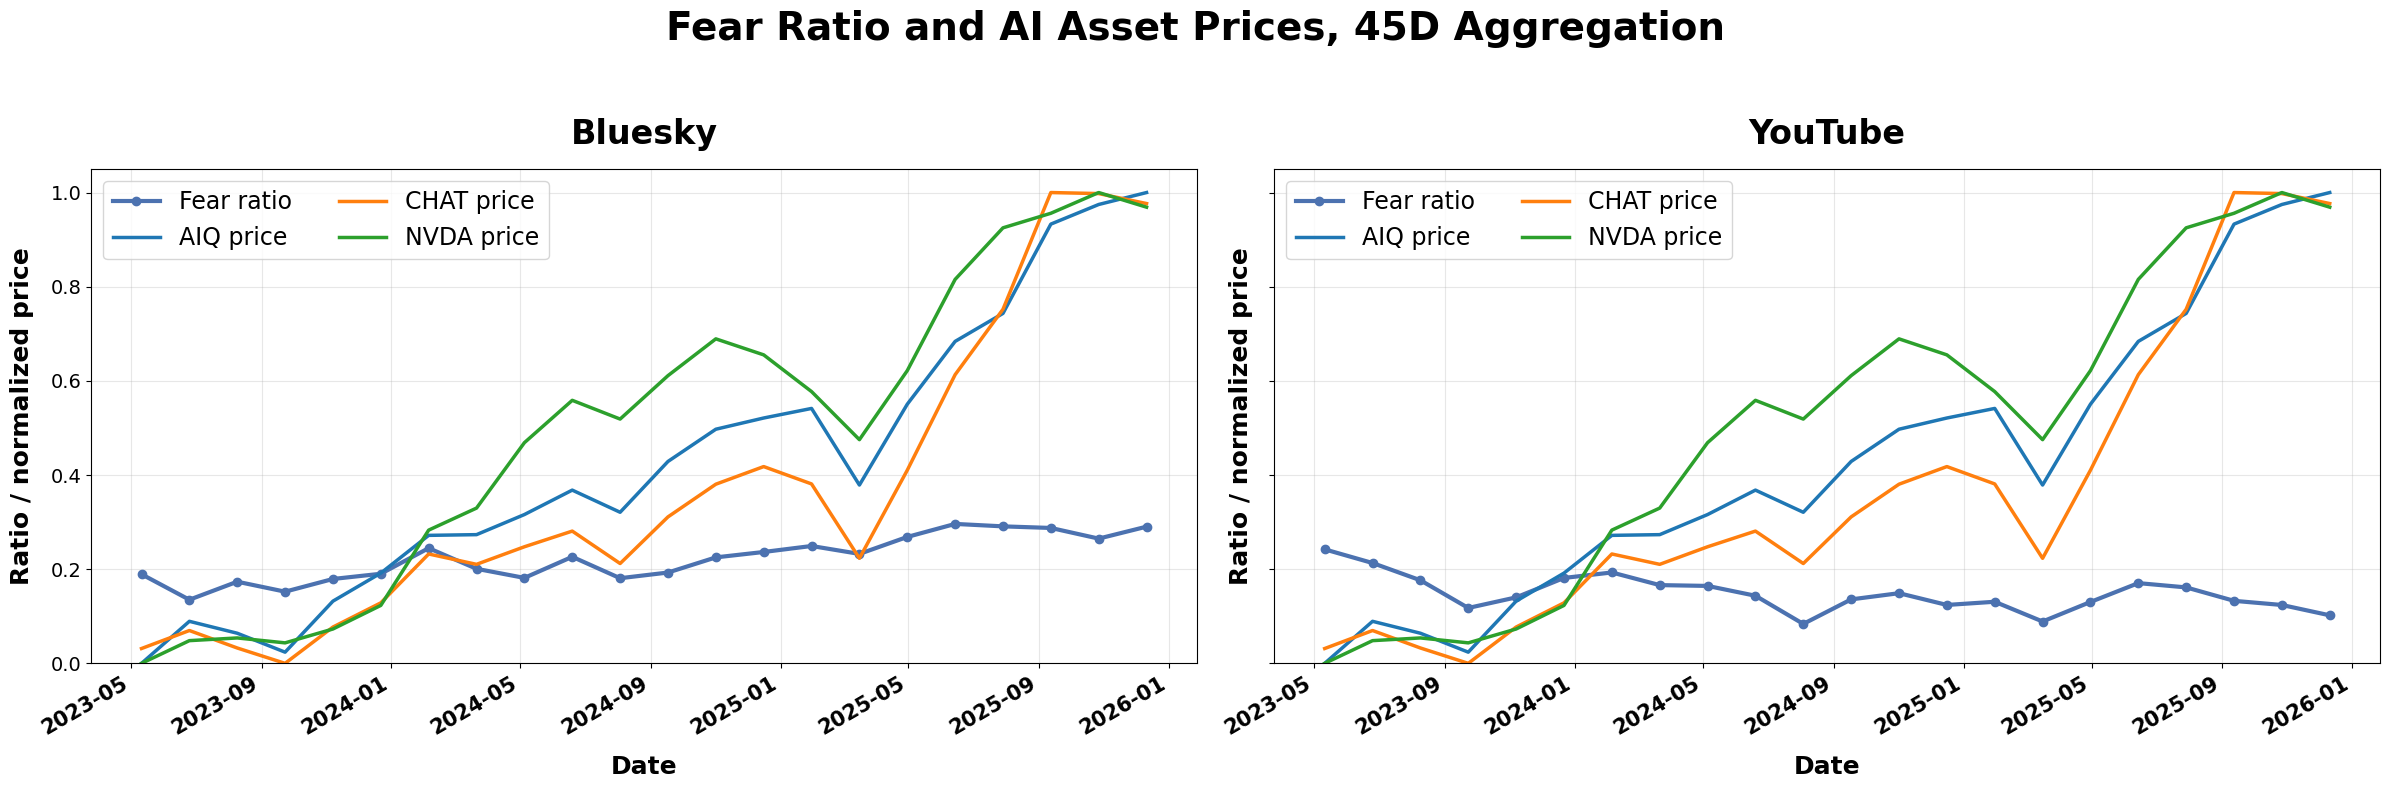

In [18]:
combined_fear_asset_fig, combined_fear_asset_axes = plot_combined_fear_ratio_with_prices(
    {"Bluesky": bsky_fear_assets, "YouTube": youtube_fear_assets},
    output_path=PLOTS_DIR / f"combined_fear_ratio_assets_{AGGREGATION_LABEL}.png",
)
plt.show()

In [19]:
# Combined in the previous cell.


,Bluesky,YouTube
AIQ,0.872728,-0.455652
CHAT,0.846358,-0.355570
NVDA,0.844556,-0.498117


Saved plot to ../data/final_plots/fear_ratio_asset_correlations_45d.png


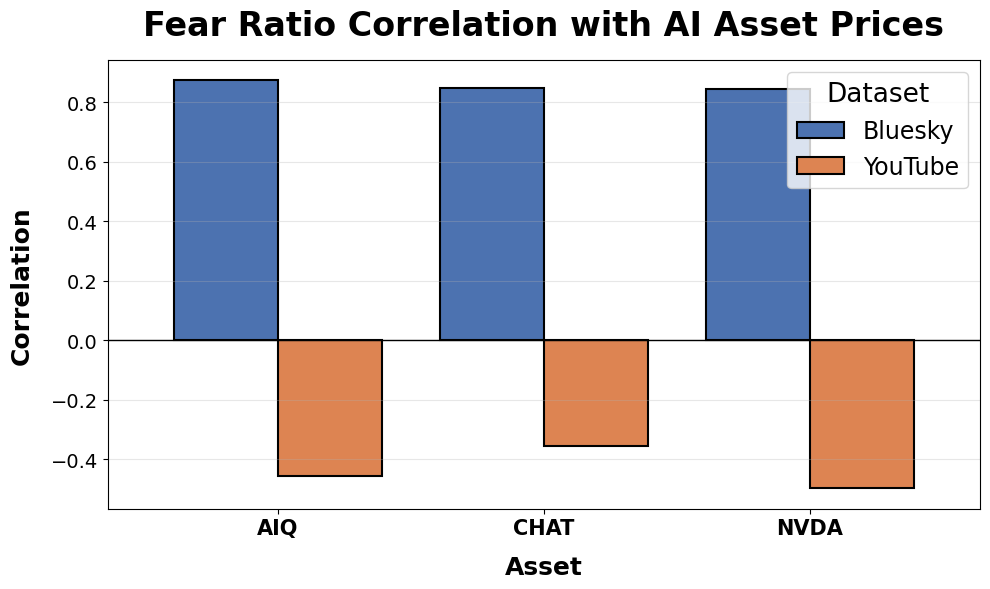

In [20]:
fear_price_correlations_df = pd.DataFrame({
    "Bluesky": fear_price_correlations(bsky_fear_assets),
    "YouTube": fear_price_correlations(youtube_fear_assets),
})

display(fear_price_correlations_df)

fear_correlation_fig, fear_correlation_ax = plot_fear_price_correlations(
    fear_price_correlations_df,
    output_path=PLOTS_DIR / f"fear_ratio_asset_correlations_{AGGREGATION_LABEL}.png",
)
plt.show()

# AI-related groups for top emotions

In [21]:
def top_emotions(df, emotion_col="Emotion", top_n=3):
    filtered_df = df[df[emotion_col].str.lower() != "neutral"].copy()
    return filtered_df[emotion_col].str.lower().value_counts(normalize=True).head(top_n).index.tolist()


def ai_group_proportions_for_top_emotions(
    df,
    emotion_col="Emotion",
    group_col="AI_RELATED_GROUP",
    top_n=3,
):
    selected_emotions = top_emotions(df, emotion_col=emotion_col, top_n=top_n)
    group_df = df.copy()
    group_df[emotion_col] = group_df[emotion_col].str.lower()
    group_df = group_df[group_df[emotion_col].isin(selected_emotions)]

    counts = (
        group_df
        .groupby([emotion_col, group_col])
        .size()
        .unstack(fill_value=0)
        .reindex(index=selected_emotions)
    )
    proportions = counts.div(counts.sum(axis=1), axis=0).fillna(0)
    return proportions


def plot_ai_group_proportions_for_top_emotions(
    df,
    dataset_name,
    output_path,
    emotion_col="Emotion",
    group_col="AI_RELATED_GROUP",
    top_n=3,
):
    proportions = ai_group_proportions_for_top_emotions(
        df,
        emotion_col=emotion_col,
        group_col=group_col,
        top_n=top_n,
    )

    fig, ax = plt.subplots(figsize=(14, 7))
    proportions.plot(kind="bar", ax=ax, colormap="tab20", width=0.85)

    ax.set_title(f"{dataset_name} AI-Related Group Proportions for Top {top_n} Emotions")
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Proportion of posts")
    ax.set_ylim(0, max(proportions.max().max() * 1.2, 0.05))
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="AI-related group", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.xticks(rotation=0)
    plt.tight_layout()

    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot to {output_path}")
    return fig, ax, proportions


In [22]:
# Combined in the combined AI-related groups cell below.


In [23]:
# Combined in the combined AI-related groups cell below.


# Combined AI-related groups for top emotions

Saved plot to ../data/final_plots/combined_top_emotions_ai_related_groups.png


AI_RELATED_GROUP,AI Products & Models,AI Research & Education,Creative AI,Financial Speculation or Markets,General AI Discussion,Societal or Environmental Impact & Fear,Software Dev
Emotion,,,,,,,
joy,0.297923,0.114540,0.124036,0.135312,0.207122,0.065282,0.055786
fear,0.187077,0.139077,0.062769,0.160000,0.223385,0.193231,0.034462
surprise,0.323567,0.043949,0.052866,0.268790,0.226752,0.052866,0.031210


AI_RELATED_GROUP,AI Products & Models,AI Research & Education,Creative AI,Financial Speculation or Markets,General AI Discussion,Societal or Environmental Impact & Fear,Software Dev
Emotion,,,,,,,
disgust,0.071115,0.033101,0.134213,0.028963,0.475045,0.202224,0.055340
anger,0.056897,0.034416,0.090758,0.028865,0.505967,0.246184,0.036914
fear,0.033693,0.021563,0.072327,0.032345,0.407907,0.389937,0.042228


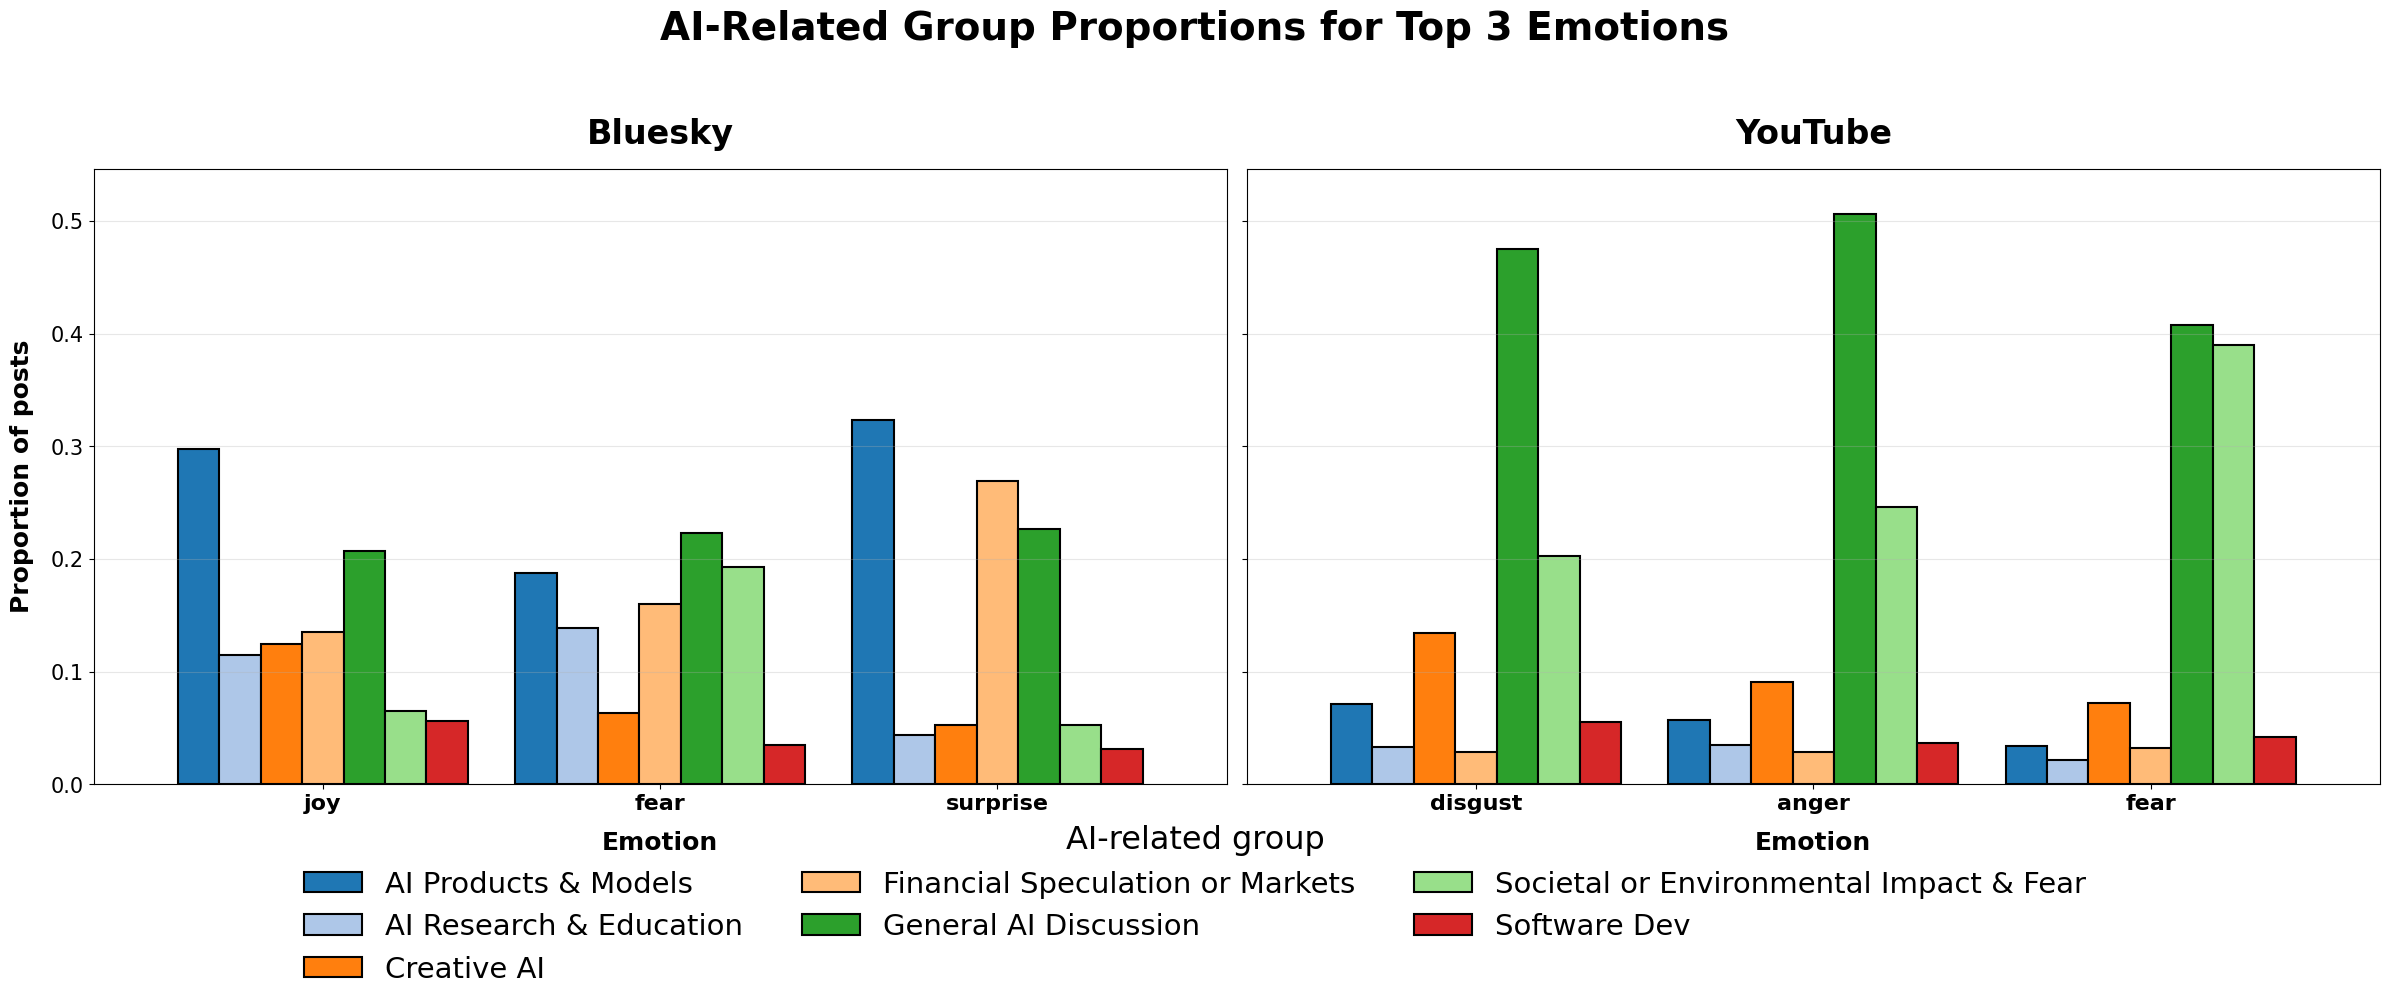

In [24]:
def plot_combined_ai_group_proportions_for_top_emotions(
    datasets,
    output_path,
    emotion_col="Emotion",
    group_col="AI_RELATED_GROUP",
    top_n=3,
):
    proportions_by_dataset = {
        dataset_name: ai_group_proportions_for_top_emotions(
            df,
            emotion_col=emotion_col,
            group_col=group_col,
            top_n=top_n,
        )
        for dataset_name, df in datasets.items()
    }

    all_groups = sorted(
        set().union(*(proportions.columns for proportions in proportions_by_dataset.values()))
    )
    max_value = max(
        proportions.reindex(columns=all_groups, fill_value=0).max().max()
        for proportions in proportions_by_dataset.values()
    )
    y_limit = max_value * 1.08

    fig, axes = plt.subplots(
        1,
        len(proportions_by_dataset),
        figsize=(24, 10),
        sharey=True,
    )
    if len(proportions_by_dataset) == 1:
        axes = [axes]

    colors = plt.get_cmap("tab20").colors[:len(all_groups)]
    legend_handles = None
    legend_labels = None

    for ax, (dataset_name, proportions) in zip(axes, proportions_by_dataset.items()):
        plot_data = proportions.reindex(columns=all_groups, fill_value=0)
        plot_data.plot(
            kind="bar",
            ax=ax,
            color=colors,
            width=0.86,
            edgecolor="black",
            linewidth=1.5,
            legend=False,
        )

        ax.set_title(dataset_name, fontsize=24, fontweight="bold", pad=18)
        ax.set_xlabel("Emotion", fontsize=18, fontweight="bold", labelpad=12)
        ax.set_ylabel("Proportion of posts", fontsize=18, fontweight="bold", labelpad=12)
        ax.set_ylim(0, y_limit)
        ax.grid(axis="y", alpha=0.3)
        ax.tick_params(axis="x", labelrotation=0, labelsize=16)
        ax.tick_params(axis="y", labelsize=15)
        for tick_label in ax.get_xticklabels():
            tick_label.set_fontweight("bold")

        handles, labels = ax.get_legend_handles_labels()
        if handles:
            legend_handles, legend_labels = handles, labels

    fig.suptitle(
        f"AI-Related Group Proportions for Top {top_n} Emotions",
        fontsize=28,
        fontweight="bold",
        y=0.98,
    )
    fig.legend(
        legend_handles,
        legend_labels,
        title="AI-related group",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=3,
        fontsize=21,
        title_fontsize=23,
        frameon=False,
    )
    fig.tight_layout(rect=(0, 0.12, 1, 0.94))

    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot to {output_path}")
    return fig, axes, proportions_by_dataset


combined_top_ai_groups_fig, combined_top_ai_groups_axes, combined_top_ai_groups = plot_combined_ai_group_proportions_for_top_emotions(
    {"Bluesky": bsky_df, "YouTube": youtube_df},
    output_path=PLOTS_DIR / "combined_top_emotions_ai_related_groups.png",
)

display(combined_top_ai_groups["Bluesky"])
display(combined_top_ai_groups["YouTube"])
plt.show()

# Bluesky posts per month

Saved plot to ../data/final_plots/bsky_preprocessed_posts_count_per_month.png


,Date,Post counts per month
0,2022-01-01 00:00:00+00:00,57
1,2022-02-01 00:00:00+00:00,49
2,2022-03-01 00:00:00+00:00,69
3,2022-04-01 00:00:00+00:00,56
4,2022-05-01 00:00:00+00:00,58
5,2022-06-01 00:00:00+00:00,83
6,2022-07-01 00:00:00+00:00,64
7,2022-08-01 00:00:00+00:00,79
8,2022-09-01 00:00:00+00:00,71
9,2022-10-01 00:00:00+00:00,68


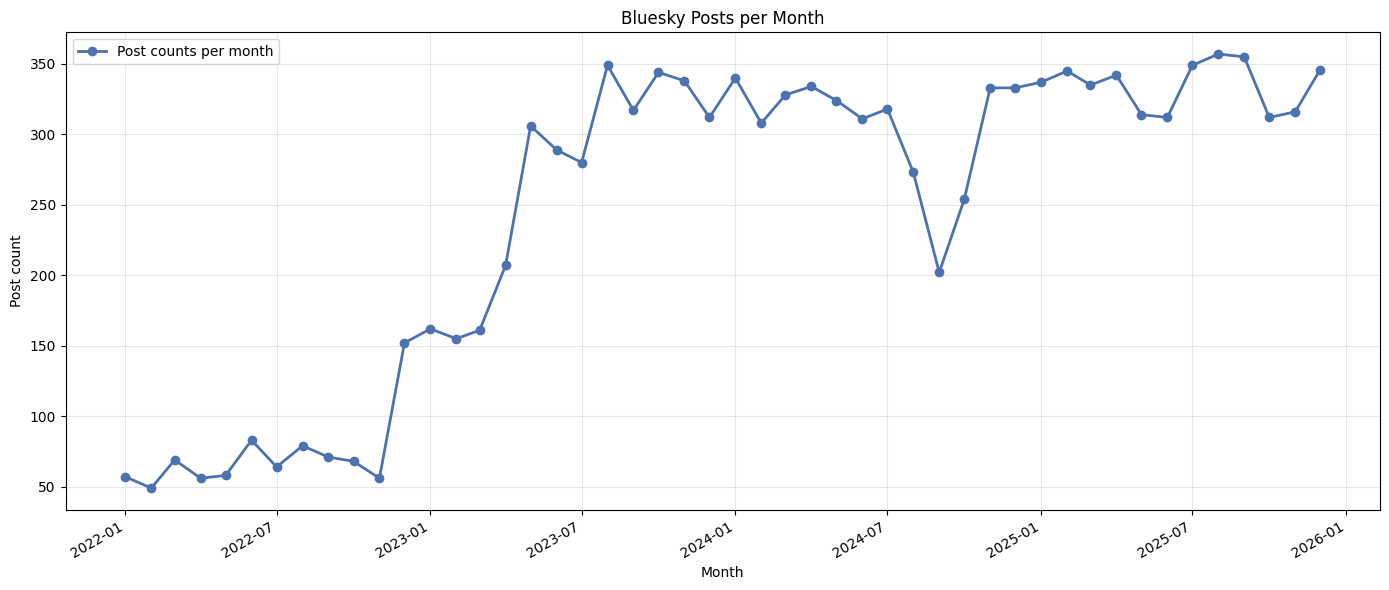

In [25]:
CLEAN_BSKY_PATH = VERSION_DIR / "clean_posts_bsky.csv"

clean_bsky_df = pd.read_csv(CLEAN_BSKY_PATH)
clean_bsky_df["Date"] = pd.to_datetime(
    clean_bsky_df["Date"],
    utc=True,
    errors="coerce",
    format="mixed",
)

monthly_post_counts = (
    clean_bsky_df
    .dropna(subset=["Date"])
    .set_index("Date")
    .resample("MS")
    .size()
    .rename("Post counts per month")
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(
    monthly_post_counts.index,
    monthly_post_counts.values,
    marker="o",
    linewidth=2,
    label="Post counts per month",
    color="#4C72B0",
)

ax.set_title("Bluesky Posts per Month")
ax.set_xlabel("Month")
ax.set_ylabel("Post count")
ax.grid(True, alpha=0.3)
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()

plot_path = PLOTS_DIR / "bsky_preprocessed_posts_count_per_month.png"
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to {plot_path}")
display(monthly_post_counts.reset_index())
plt.show()